
Independent T-test:
T-statistic: -1.9532
P-value: 0.0508


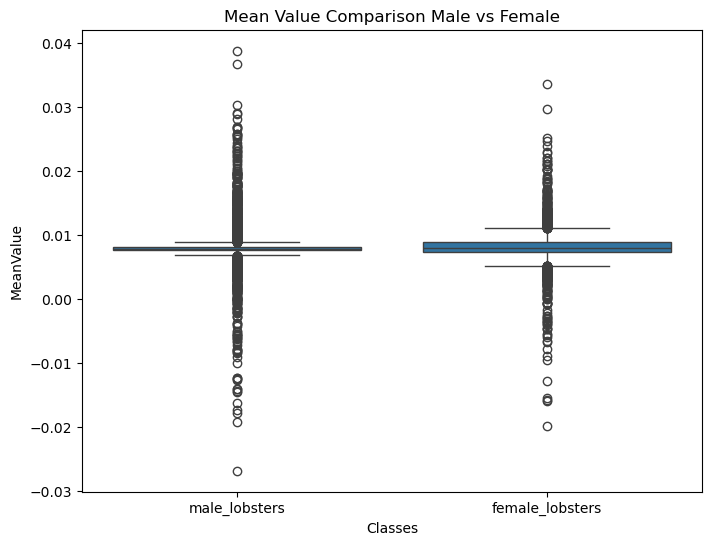

                     mean       std  count
Classes                                   
female_lobsters  0.008178  0.002884   2900
male_lobsters    0.008036  0.003146   4407


In [10]:
import librosa
import numpy as np
import os
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns



def compute_audio_stats(audio_folders, folder_names):
    """Computes mean, standard deviation, and count for audio segments in folders.

    Args:
        audio_folders: List of folder paths.
        folder_names: List of folder names.

    Returns:
        DataFrame: Summary statistics, and performs t-test.
    """
    data = []
    for i, folder in enumerate(audio_folders):
        values = []
        for file in os.listdir(folder):
            if file.endswith(('.wav', '.mp3', '.flac')):
                try:
                    y, sr = librosa.load(os.path.join(folder, file), duration=1)
                    if len(y) != sr: print(f"Warning: {file} in {folder_names[i]} not 1s")
                    values.append(np.mean(y))  # Use mean of audio as the value
                except Exception as e: print(f"Error: {file} in {folder_names[i]}: {e}")
        data.extend([(folder_names[i], val) for val in values])

    df = pd.DataFrame(data, columns=['Classes', 'MeanValue'])
    summary = df.groupby('Classes')['MeanValue'].agg(['mean', 'std', 'count'])

    if len(audio_folders) == 2:
        group1 = df[df['Classes'] == folder_names[0]]['MeanValue']
        group2 = df[df['Classes'] == folder_names[1]]['MeanValue']
        t_stat, p_value = stats.ttest_ind(group1, group2)
        print("\nIndependent T-test:")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.4f}")

    # Boxplot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Classes', y='MeanValue', data=df)
    plt.title("Mean Value Comparison Male vs Female")
    plt.show()

    return summary

# Example usage:
audio_folders = ["/home/feliciano/male_lobsters", "/home/feliciano/female_lobsters"]
folder_names = ["male_lobsters", "female_lobsters"]
stats_df = compute_audio_stats(audio_folders, folder_names)
print(stats_df)